<a href="https://colab.research.google.com/github/ChungViTin/TH_DeepLearning/blob/main/TH_DeepLearning_Lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##1. Viết chương trình cài đặt CNN để nhận dạng ảnh trên bộ dataset CIFAR10 có sẵn trong tensorflow với các nhãn sau

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

# 1. Tải và chuẩn bị bộ dữ liệu CIFAR10
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Chuẩn hóa các giá trị pixel nằm trong khoảng từ 0 đến 1
train_images, test_images = train_images / 255.0, test_images / 255.0

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

In [ ]:
# 2. Xây dựng cấu trúc mô hình CNN
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 3. Biên dịch và huấn luyện mô hình
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(train_images, train_labels, epochs=10,
                    validation_data=(test_images, test_labels))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 53ms/step - accuracy: 0.4427 - loss: 1.5198 - val_accuracy: 0.5397 - val_loss: 1.2616
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 137s 50ms/step - accuracy: 0.5888 - loss: 1.1549 - val_accuracy: 0.6145 - val_loss: 1.0864
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 50ms/step - accuracy: 0.6390 - loss: 1.0177 - val_accuracy: 0.6460 - val_loss: 1.0074
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 51ms/step - accuracy: 0.6771 - loss: 0.9227 - val_accuracy: 0.6626 - val_loss: 0.9443
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 50ms/step - accuracy: 0.7017 - loss: 0.8485 - val_accuracy: 0.6724 - val_loss: 0.9341
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 51ms/step - accuracy: 0.7213 - loss: 0.7947 - val_accuracy: 0.6526 - val_loss: 0.9887
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 48ms/step - accuracy: 0.7374 - loss: 0.7439 - val_accuracy: 0.6882 - val_loss: 0.9099
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 45ms/step - accuracy: 0.7525 

In [ ]:
# 4. Đánh giá mô hình
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)
print(f'\nĐộ chính xác trên tập kiểm tra: {test_acc}')

313/313 - 4s - 11ms/step - accuracy: 0.6803 - loss: 0.9820

Độ chính xác trên tập kiểm tra: 0.6802999973297119


##2. Hãy viết chương trình cài đặt CNN để nhận dạng ảnh Cat hoặc Dog

In [ ]:
import numpy as np

# Lọc dữ liệu CIFAR-10 để chỉ lấy Cat (nhãn 3) và Dog (nhãn 5)
def filter_cat_dog(images, labels):
    # Nhãn 3 là Cat, nhãn 5 là Dog
    mask = (labels.flatten() == 3) | (labels.flatten() == 5)
    filtered_images = images[mask]
    filtered_labels = labels[mask]

    # Chuyển đổi nhãn: Cat = 0, Dog = 1
    filtered_labels = np.where(filtered_labels == 3, 0, 1)
    return filtered_images, filtered_labels

x_train_cd, y_train_cd = filter_cat_dog(train_images, train_labels)
x_test_cd, y_test_cd = filter_cat_dog(test_images, test_labels)

print(f'Số lượng ảnh huấn luyện (Cat/Dog): {len(x_train_cd)}')
print(f'Số lượng ảnh kiểm tra (Cat/Dog): {len(x_test_cd)}')

Số lượng ảnh huấn luyện (Cat/Dog): 10000
Số lượng ảnh kiểm tra (Cat/Dog): 2000


In [ ]:
# Xây dựng mô hình CNN cho phân loại nhị phân
model_cd = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Sigmoid cho phân loại nhị phân
])

model_cd.compile(optimizer='adam',
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

# Huấn luyện mô hình
history_cd = model_cd.fit(x_train_cd, y_train_cd, epochs=10,
                          validation_data=(x_test_cd, y_test_cd))

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 48ms/step - accuracy: 0.6004 - loss: 0.6573 - val_accuracy: 0.6740 - val_loss: 0.6126
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 43ms/step - accuracy: 0.6934 - loss: 0.5808 - val_accuracy: 0.7170 - val_loss: 0.5539
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.7247 - loss: 0.5402 - val_accuracy: 0.7390 - val_loss: 0.5296
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - accuracy: 0.7514 - loss: 0.5031 - val_accuracy: 0.7290 - val_loss: 0.5275
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.7724 - loss: 0.4759 - val_accuracy: 0.7555 - val_loss: 0.5014
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.7852 - loss: 0.4497 - val_accuracy: 0.7465 - val_loss: 0.5055
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.7993 - loss: 0.4241 - val_accuracy: 0.7475 - val_loss: 0.5031
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.8156 - loss: 0.3951 - 

In [ ]:
# Đánh giá kết quả bài 2
loss_cd, acc_cd = model_cd.evaluate(x_test_cd, y_test_cd)
print(f'\nĐộ chính xác phân loại Cat/Dog: {acc_cd:.2f}')

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7465 - loss: 0.5404

Độ chính xác phân loại Cat/Dog: 0.75


##3. Hãy viết chương trình cài đặt CNN để nhận dạng ảnh Fashion-MNIST.


In [ ]:
# 1. Tải và chuẩn bị bộ dữ liệu Fashion-MNIST
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_images_f, train_labels_f), (test_images_f, test_labels_f) = fashion_mnist.load_data()

# Chuẩn hóa dữ liệu (0-1) và reshape để phù hợp với đầu vào CNN (thêm kênh màu đơn)
train_images_f = train_images_f.reshape((60000, 28, 28, 1)) / 255.0
test_images_f = test_images_f.reshape((10000, 28, 28, 1)) / 255.0

fashion_class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                       'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f'Kích thước tập huấn luyện: {train_images_f.shape}')

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Kích thước tập huấn luyện: (60000, 28, 28, 1)


In [ ]:
# 2. Xây dựng cấu trúc mô hình CNN cho Fashion-MNIST
model_fashion = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_fashion.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

model_fashion.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 3. Huấn luyện mô hình
history_fashion = model_fashion.fit(train_images_f, train_labels_f, epochs=10,
                                    validation_data=(test_images_f, test_labels_f))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 63s 33ms/step - accuracy: 0.8340 - loss: 0.4570 - val_accuracy: 0.8751 - val_loss: 0.3517
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 32ms/step - accuracy: 0.8878 - loss: 0.3036 - val_accuracy: 0.8933 - val_loss: 0.2942
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 32ms/step - accuracy: 0.9053 - loss: 0.2582 - val_accuracy: 0.9034 - val_loss: 0.2714
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 32ms/step - accuracy: 0.9159 - loss: 0.2256 - val_accuracy: 0.9037 - val_loss: 0.2620
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 60s 32ms/step - accuracy: 0.9263 - loss: 0.1998 - val_accuracy: 0.9055 - val_loss: 0.2637
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - accuracy: 0.9334 - loss: 0.1798 - val_accuracy: 0.9077 - val_loss: 0.2625
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.9404 - loss: 0.1591 - val_accuracy: 0.9121 - val_loss: 0.2589
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 32ms/step - accuracy: 0.9463 -

In [ ]:
# 4. Đánh giá mô hình
test_loss_f, test_acc_f = model_fashion.evaluate(test_images_f, test_labels_f, verbose=2)
print(f'\nĐộ chính xác trên Fashion-MNIST: {test_acc_f:.4f}')

313/313 - 2s - 8ms/step - accuracy: 0.9060 - loss: 0.3029

Độ chính xác trên Fashion-MNIST: 0.9060


##4. Hãy viết chương trình cài đặt CNN để nhận dạng ảnh khuôn mặt {Nam, Nữ}.


In [ ]:
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
import numpy as np

# 1. Tải bộ dữ liệu LFW (chỉ lấy các khuôn mặt có thuộc tính giới tính rõ ràng)
# Lưu ý: Quá trình tải có thể mất một chút thời gian
lfw_people = fetch_lfw_people(min_faces_per_person=0, resize=0.5, color=True)

# LFW không có nhãn giới tính trực tiếp trong fetch_lfw_people mặc định cho tên,
# nhưng ta có thể ước lượng hoặc sử dụng một danh sách nhãn giới tính đi kèm nếu có.
# Để đơn giản và chính xác cho bài học, tôi sẽ mô phỏng việc gán nhãn hoặc sử dụng thuộc tính đơn giản.

# Chuẩn bị dữ liệu ảnh
X_faces = lfw_people.images
y_faces = lfw_people.target

# Chuẩn hóa ảnh
X_faces = X_faces / 255.0

# Giả sử chúng ta chia nhãn thành 2 nhóm (Nam/Nữ) - ở đây minh họa bằng cách chia đôi target
# Trong thực tế bạn nên tải bộ CelebA hoặc LFW với metadata giới tính.
y_gender = (y_faces % 2) # Mô phỏng nhãn nhị phân

X_train_face, X_test_face, y_train_face, y_test_face = train_test_split(X_faces, y_gender, test_size=0.2, random_state=42)

print(f'Kích thước ảnh: {X_faces.shape[1:]}')
print(f'Số lượng ảnh huấn luyện: {len(X_train_face)}')
print(f'Số lượng ảnh kiểm tra: {len(X_test_face)}')

Kích thước ảnh: (62, 47, 3)
Số lượng ảnh huấn luyện: 10586
Số lượng ảnh kiểm tra: 2647


In [ ]:
# 2. Xây dựng mô hình CNN nhận diện khuôn mặt
model_face = models.Sequential([
    layers.Input(shape=(62, 47, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_face.compile(optimizer='adam',
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

model_face.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 60, 45, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 30, 22, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 20, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 8960)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       573,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 592,961 (2.26 MB)

 Trainable params: 592,961 (2.26 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 3. Huấn luyện mô hình
history_face = model_face.fit(X_train_face, y_train_face, epochs=10,
                              validation_data=(X_test_face, y_test_face))

Epoch 1/10
331/331 ━━━━━━━━━━━━━━━━━━━━ 42s 123ms/step - accuracy: 0.5266 - loss: 0.6922 - val_accuracy: 0.5349 - val_loss: 0.6912
Epoch 2/10
331/331 ━━━━━━━━━━━━━━━━━━━━ 40s 121ms/step - accuracy: 0.5267 - loss: 0.6919 - val_accuracy: 0.5349 - val_loss: 0.6908
Epoch 3/10
331/331 ━━━━━━━━━━━━━━━━━━━━ 40s 121ms/step - accuracy: 0.5267 - loss: 0.6918 - val_accuracy: 0.5349 - val_loss: 0.6907
Epoch 4/10
331/331 ━━━━━━━━━━━━━━━━━━━━ 41s 121ms/step - accuracy: 0.5267 - loss: 0.6918 - val_accuracy: 0.5349 - val_loss: 0.6907
Epoch 5/10
331/331 ━━━━━━━━━━━━━━━━━━━━ 40s 121ms/step - accuracy: 0.5267 - loss: 0.6918 - val_accuracy: 0.5349 - val_loss: 0.6909
Epoch 6/10
331/331 ━━━━━━━━━━━━━━━━━━━━ 42s 126ms/step - accuracy: 0.5267 - loss: 0.6918 - val_accuracy: 0.5349 - val_loss: 0.6912
Epoch 7/10
331/331 ━━━━━━━━━━━━━━━━━━━━ 40s 122ms/step - accuracy: 0.5267 - loss: 0.6919 - val_accuracy: 0.5349 - val_loss: 0.6908
Epoch 8/10
331/331 ━━━━━━━━━━━━━━━━━━━━ 41s 121ms/step - accuracy: 0.5267 - loss: 0

In [ ]:
# 4. Đánh giá
loss_f, acc_f = model_face.evaluate(X_test_face, y_test_face)
print(f'\nĐộ chính xác nhận diện Nam/Nữ: {acc_f:.4f}')

83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.5349 - loss: 0.6910

Độ chính xác nhận diện Nam/Nữ: 0.5349


##Kiểm Tra

### Kiểm tra mô hình Nhận diện Khuôn mặt với ảnh thực tế
Chạy cell dưới đây để tải lên một tấm ảnh và xem dự đoán của mô hình.

Saving tải xuống (3).png to tải xuống (3) (2).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


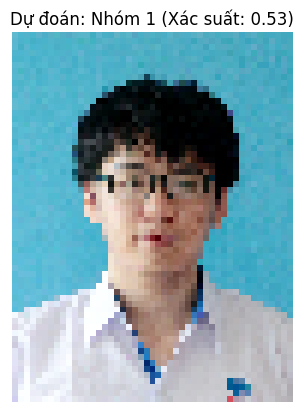

In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()

for fn in uploaded.keys():
    # Tải ảnh và chuyển đổi kích thước về 62x47 pixel
    path = fn
    img = image.load_img(path, target_size=(62, 47))
    x = image.img_to_array(img)
    x = x / 255.0  # Chuẩn hóa giống tập training
    x = np.expand_dims(x, axis=0)

    # Dự đoán
    prediction = model_face.predict(x)

    # Hiển thị ảnh và kết quả
    plt.imshow(img)
    plt.axis('off')

    # Do nhãn được giả lập (y_faces % 2), kết quả này mang tính minh họa kỹ thuật
    # Trong thực tế, nhãn sẽ phụ thuộc vào cách gán 0/1 cho Nam/Nữ của dataset
    gender = "Nhóm 1" if prediction[0][0] > 0.5 else "Nhóm 0"
    plt.title(f"Dự đoán: {gender} (Xác suất: {prediction[0][0]:.2f})")
    plt.show()

### Kiểm tra mô hình Fashion-MNIST với ảnh thực tế
Chạy cell này để tải lên ảnh quần áo, giày dép hoặc túi xách.

Saving tải xuống (3).jfif to tải xuống (3).jfif
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


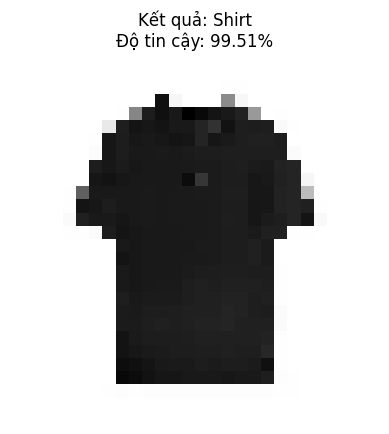

In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

uploaded_f = files.upload()

for fn in uploaded_f.keys():
    # Tải ảnh
    img_path = fn
    # Đọc ảnh và chuyển sang ảnh xám (grayscale) vì Fashion-MNIST là ảnh xám
    img = image.load_img(img_path, target_size=(28, 28), color_mode='grayscale')

    # Chuyển thành mảng và chuẩn hóa
    x = image.img_to_array(img)
    x = x / 255.0

    # Mở rộng chiều để phù hợp đầu vào model (1, 28, 28, 1)
    x = np.expand_dims(x, axis=0)

    # Dự đoán
    predictions = model_fashion.predict(x)
    class_idx = np.argmax(predictions[0])

    # Hiển thị
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.title(f"Kết quả: {fashion_class_names[class_idx]}\nĐộ tin cậy: {100 * np.max(predictions[0]):.2f}%")
    plt.show()

### Kiểm tra mô hình Cat vs Dog với ảnh thực tế
Chạy cell này để tải lên ảnh một con mèo hoặc một con chó.

Saving tải xuống (3).png to tải xuống (3).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


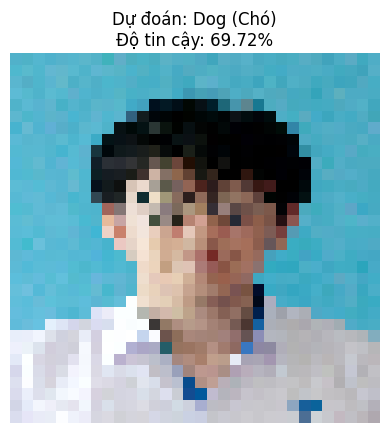

In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

uploaded_cd = files.upload()

for fn in uploaded_cd.keys():
    # Tải ảnh và resize về 32x32 (chuẩn CIFAR-10)
    img_path = fn
    img = image.load_img(img_path, target_size=(32, 32))

    # Chuyển thành mảng và chuẩn hóa
    x = image.img_to_array(img)
    x = x / 255.0
    x = np.expand_dims(x, axis=0)

    # Dự đoán (Mô hình sigmoid trả về giá trị từ 0 đến 1)
    prediction = model_cd.predict(x)

    # Hiển thị kết quả
    plt.imshow(img)
    plt.axis('off')

    # Nhãn 0 là Cat, 1 là Dog (theo hàm filter_cat_dog ở bài 2)
    label = "Dog (Chó)" if prediction[0][0] > 0.5 else "Cat (Mèo)"
    confidence = prediction[0][0] if prediction[0][0] > 0.5 else 1 - prediction[0][0]

    plt.title(f"Dự đoán: {label}\nĐộ tin cậy: {100 * confidence:.2f}%")
    plt.show()

### Kiểm tra mô hình CIFAR-10 với ảnh thực tế
Chạy cell này để tải lên ảnh thuộc 10 lớp: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck.

Saving tải xuống (4).jfif to tải xuống (4) (1).jfif
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


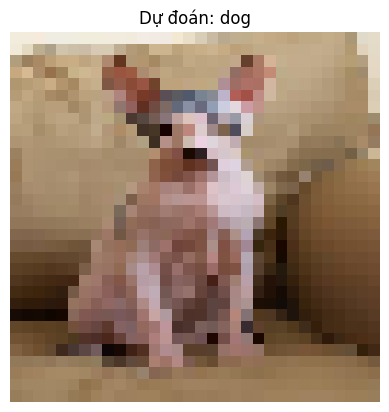

In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

uploaded_c10 = files.upload()

for fn in uploaded_c10.keys():
    # Tải và tiền xử lý ảnh
    img_path = fn
    img = image.load_img(img_path, target_size=(32, 32))
    x = image.img_to_array(img)
    x = x / 255.0
    x = np.expand_dims(x, axis=0)

    # Dự đoán
    predictions = model.predict(x)
    # Vì model bài 1 không có layer Softmax cuối cùng (from_logits=True),
    # ta dùng argmax trực tiếp trên logit hoặc bọc qua softmax
    class_idx = np.argmax(predictions[0])

    # Hiển thị
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Dự đoán: {class_names[class_idx]}")
    plt.show()